# Segment Tree
### リファレンス
- [Segment Tree（セグメント木）による重み付きランダムサンプリング](https://horomary.hatenablog.com/entry/2021/02/16/005113)

### A. numpy.choiceによる重み付きランダムサンプリング

In [2]:
import numpy as np
import time

N = 1000000
batch_size = 32
indices = np.arange(N)
priorities = np.random.rand(N)

s = time.time()
for _ in range(200):
    probs = priorities / priorities.sum()
    np.random.choice(indices, size=batch_size, p=probs)

print("経過時間", time.time() - s)

経過時間 1.8064320087432861


### B. 累積和による重み付きランダムサンプリング

length of sampled: 100


(array([43.,  0.,  0., 18.,  0.,  0., 12.,  0.,  0., 27.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

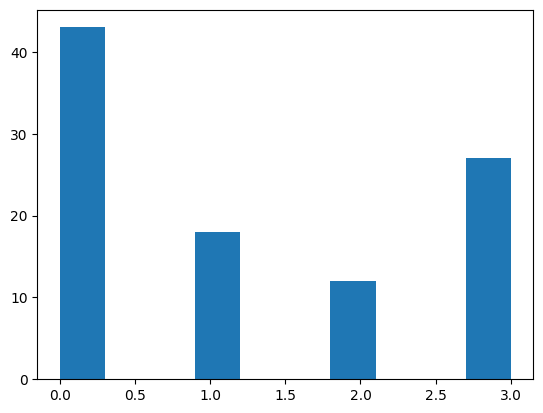

In [7]:
import random
import matplotlib.pyplot as plt

priorities = [4, 2, 1, 3]
sampled = []
for _ in range(100):
    # たとえば、4要素のリストにおいて各要素の優先度が [4, 2, 1, 3] のときは、
    # 0 ≦ z ≦ 4+2+1+3 = 10 の範囲で一様乱数を発生させ、累積和がzとなるのがどの要素のときかを調べることで
    # 優先度に従ったサンプリングを行うことができます。
    z = random.uniform(0, sum(priorities))
    cumsum = 0
    for idx, priority in enumerate(priorities):
        cumsum += priority
        if cumsum >= z:
            sampled.append(idx)
            break   

print('length of sampled:', len(sampled))
plt.hist(sampled)

In [8]:
import random
import numpy as np
import time

N = 1000000
batch_size = 32
indices = np.arange(N)
priorities = np.random.randint(0, 5, size=N)

s = time.time()
for _ in range(200):
    total_priority = priorities.sum()
    z_list = sorted([random.randint(0, total_priority) for _ in range(batch_size)])
    sampled = []
    custom = 0
    target = 0

    for idx, priority in enumerate(priorities):
        custom += priority
        while target < len(z_list) and z_list[target] <= custom:
            sampled.append(idx)
            target += 1
        if target == len(z_list):
            break

print("経過時間", time.time() - s)

経過時間 42.96300721168518


[3 3 1 ... 2 3 0]
length of priorities: 1000000


(array([4., 2., 6., 1., 4., 1., 1., 3., 2., 8.]),
 array([  5049. ,  86032.5, 167016. , 247999.5, 328983. , 409966.5,
        490950. , 571933.5, 652917. , 733900.5, 814884. ]),
 <BarContainer object of 10 artists>)

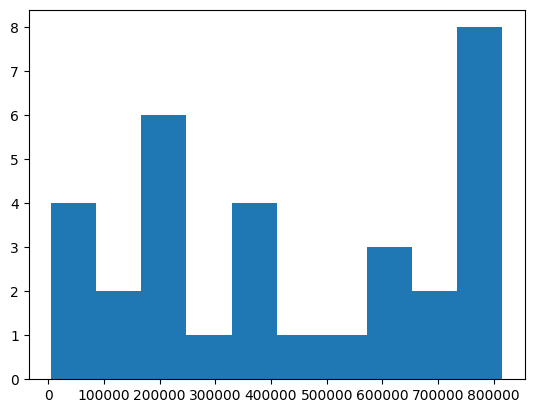

In [12]:
print(priorities)
print('length of priorities:', len(priorities))
plt.hist(sampled)

### C. Sum-tree構造を活用した重み付きランダムサンプリング

In [13]:
class SumTree:

  def __init__(self, capacity: int):
    #: 2のべき乗チェック
    assert capacity & (capacity - 1) == 0
    self.capacity = capacity
    self.values = [0 for _ in range(2 * capacity)]
  
  def __str__(self):
    return str(self.values[self.capacity:])
  
  def __setitem__(self, idx, val):
    idx = idx + self.capacity
    self.values[idx] = val

    current_idx = idx // 2
    while current_idx >= 1:
      idx_lchild = 2 * current_idx
      idx_rchild = 2 * current_idx + 1
      self.values[current_idx] = self.values[idx_lchild] + self.values[idx_rchild]
      current_idx //= 2

  def __getitem__(self, idx):
    idx = idx + self.capacity
    return self.value[idx]
  
  def sum(self):
    return self.values[1] 

  def sample(self, z=None):
    z = random.uniform(0, self.sum()) if z is None else z
    assert 0 <= z <= self.sum()
    
    current_idx = 1
    while current_idx < self.capacity:
      
      idx_lchild = 2 * current_idx
      idx_rchild = 2 * current_idx + 1

      #: 左子ノードよりzが大きい場合は右子ノードへ
      if z > self.values[idx_lchild]:
        current_idx = idx_rchild
        z = z -self.values[idx_lchild]
      else:
        current_idx = idx_lchild
    
    #: 見かけ上のインデックスにもどす
    idx = current_idx - self.capacity
    return idx


In [14]:
sumtree = SumTree(capacity=4)
sumtree[0] = 4
sumtree[1] = 2
sumtree[2] = 1
sumtree[3] = 3

print('見かけ上の要素: ', sumtree)
print('実際の要素: ', sumtree.values)
print('合計: ', sumtree.sum())
print('累積和が6.5になるインデックス: ', sumtree.sample(z=6.5))

見かけ上の要素:  [4, 2, 1, 3]
実際の要素:  [0, 10, 6, 4, 4, 2, 1, 3]
合計:  10
累積和が6.5になるインデックス:  2


In [17]:
import numpy as np
import time

N = 1000000
batch_size = 32
indices = np.arange(N)
priorities = np.random.randint(0, 5, size=N)

# 2の20乗は1048576
sumtree = SumTree(capacity=2**20)
for i, priority in enumerate(priorities):
    sumtree[i] = priority

s = time.time()
for _ in range(200):
    sampled = [sumtree.sample() for _ in range(batch_size)]

print("経過時間", time.time() - s)

経過時間 0.032183170318603516
